# Titanic Dataset

In [2]:
pip install matplotlib seaborn

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------------------- -------------- 5.2/8.3 MB 42.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 22.1 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 48.3 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 52.0 MB/s  0:00:00

   ---------------------------------------- 0/7 [pillow]
   ---------------------------------------- 0/7 [pillow]
   ---------------------------------------- 0/7 [pillow]
   ---------------------------------------- 0/7 [pillow]
   ---------------------------------------- 0/7 [pillow]
   ---------------------------------------- 0/7 [pillow]
   -------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Hazır!")

Hazır!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Görsel stil
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Veriyi yükle
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

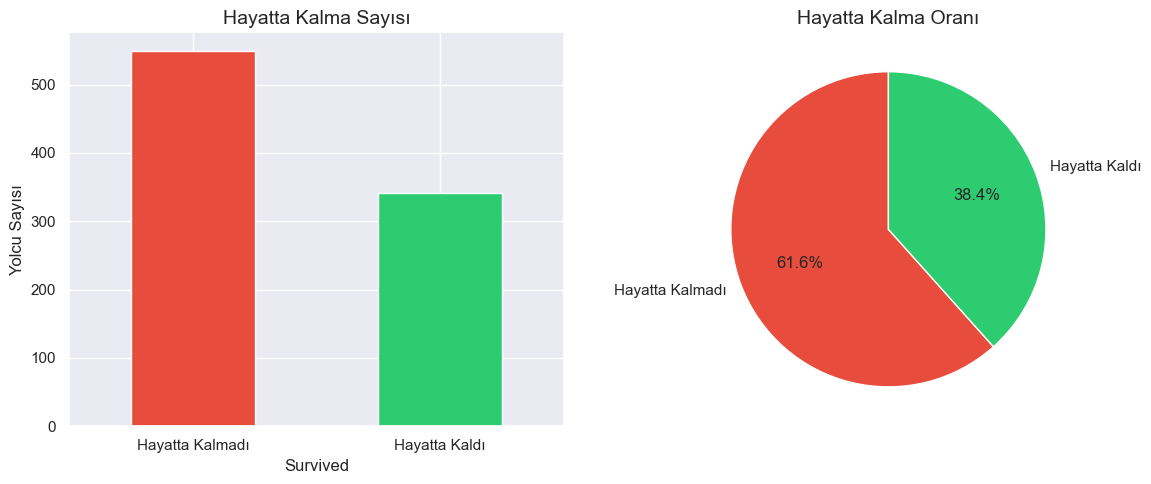

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sol: sayı
df["Survived"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#e74c3c", "#2ecc71"], edgecolor="white"
)
axes[0].set_title("Hayatta Kalma Sayısı", fontsize=14)
axes[0].set_xticklabels(["Hayatta Kalmadı", "Hayatta Kaldı"], rotation=0)
axes[0].set_ylabel("Yolcu Sayısı")

# Sağ: yüzde
df["Survived"].value_counts(normalize=True).plot(
    kind="pie", ax=axes[1],
    labels=["Hayatta Kalmadı", "Hayatta Kaldı"],
    colors=["#e74c3c", "#2ecc71"],
    autopct="%1.1f%%", startangle=90
)
axes[1].set_title("Hayatta Kalma Oranı", fontsize=14)
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("01_survival_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\Tuna\AppData\Local\Temp\ipykernel_9484\146066739.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Sex", y="Survived",
C:\Users\Tuna\AppData\Local\Temp\ipykernel_9484\146066739.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Erkek", "Kadın"])
C:\Users\Tuna\AppData\Local\Temp\ipykernel_9484\146066739.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Pclass", y="Survived",


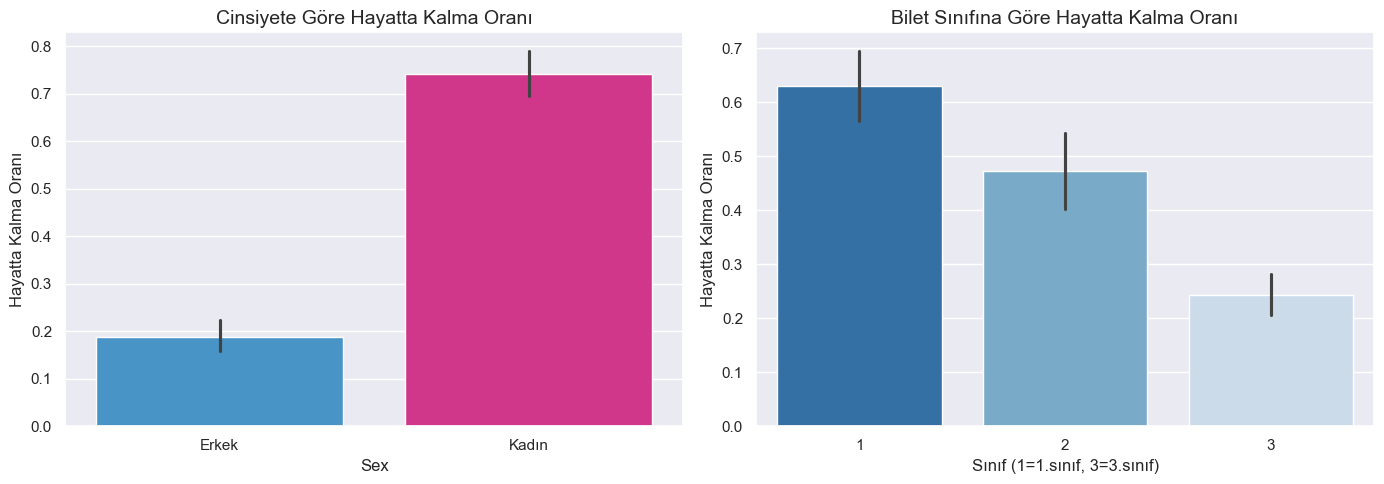

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cinsiyet
sns.barplot(data=df, x="Sex", y="Survived",
            palette=["#3498db", "#e91e8c"], ax=axes[0])
axes[0].set_title("Cinsiyete Göre Hayatta Kalma Oranı", fontsize=14)
axes[0].set_ylabel("Hayatta Kalma Oranı")
axes[0].set_xticklabels(["Erkek", "Kadın"])

# Bilet sınıfı
sns.barplot(data=df, x="Pclass", y="Survived",
            palette="Blues_r", ax=axes[1])
axes[1].set_title("Bilet Sınıfına Göre Hayatta Kalma Oranı", fontsize=14)
axes[1].set_ylabel("Hayatta Kalma Oranı")
axes[1].set_xlabel("Sınıf (1=1.sınıf, 3=3.sınıf)")

plt.tight_layout()
plt.savefig("02_sex_class_survival.png", dpi=150, bbox_inches="tight")
plt.show()

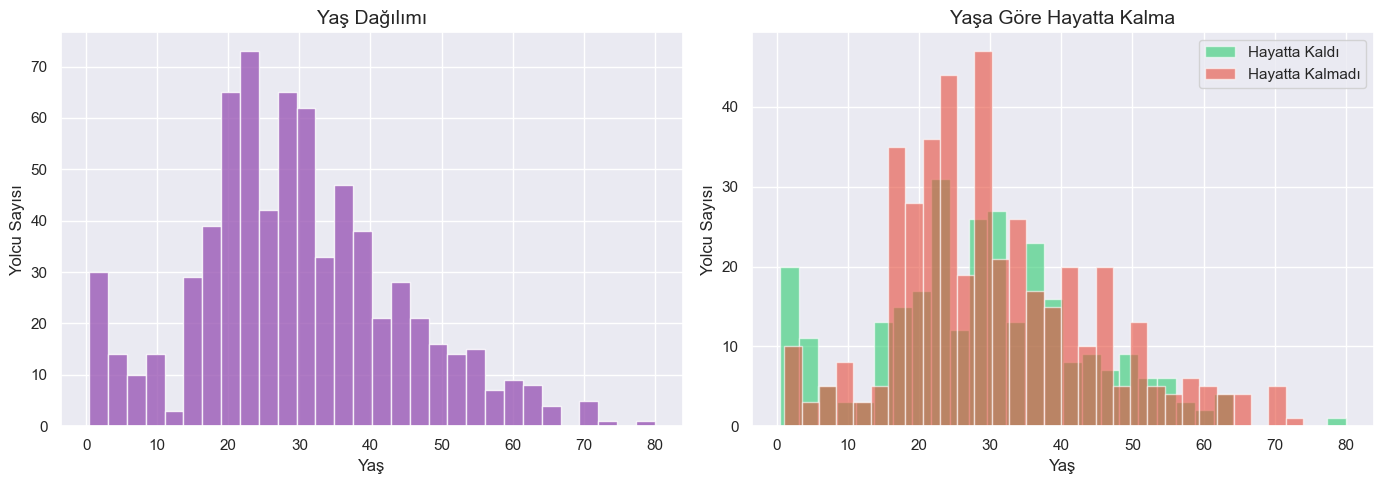

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Genel yaş dağılımı
axes[0].hist(df["Age"].dropna(), bins=30,
             color="#9b59b6", edgecolor="white", alpha=0.8)
axes[0].set_title("Yaş Dağılımı", fontsize=14)
axes[0].set_xlabel("Yaş")
axes[0].set_ylabel("Yolcu Sayısı")

# Hayatta kalan vs kalmayan yaş dağılımı
df[df["Survived"]==1]["Age"].dropna().hist(
    bins=30, ax=axes[1], alpha=0.6, color="#2ecc71", label="Hayatta Kaldı")
df[df["Survived"]==0]["Age"].dropna().hist(
    bins=30, ax=axes[1], alpha=0.6, color="#e74c3c", label="Hayatta Kalmadı")
axes[1].set_title("Yaşa Göre Hayatta Kalma", fontsize=14)
axes[1].set_xlabel("Yaş")
axes[1].set_ylabel("Yolcu Sayısı")
axes[1].legend()

plt.tight_layout()
plt.savefig("03_age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

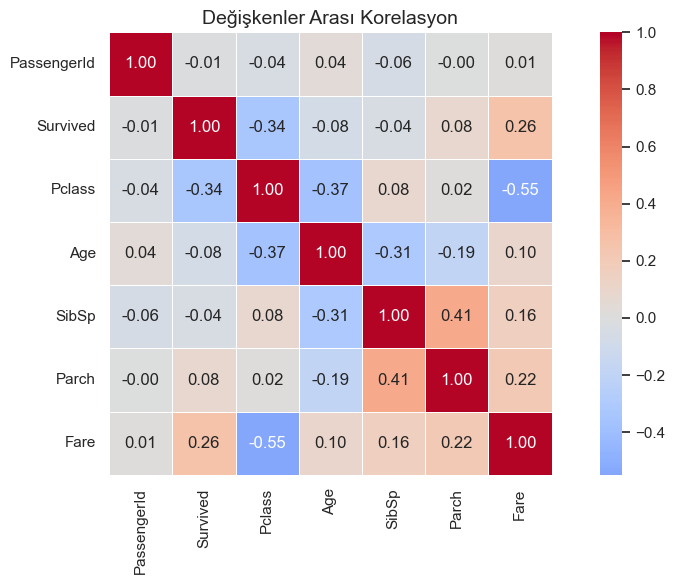

In [8]:
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Değişkenler Arası Korelasyon", fontsize=14)
plt.tight_layout()
plt.savefig("04_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Bunu çalıştır ve gözlemle
df[df["Age"] < 10]["Survived"].mean()

np.float64(0.6129032258064516)

In [11]:
pivot = df.pivot_table(
    values="Survived",
    index="Sex",
    columns="Pclass",
    aggfunc="mean"
).round(2)

print(pivot)

Pclass     1     2     3
Sex                     
female  0.97  0.92  0.50
male    0.37  0.16  0.14


🔧 Titanic Projesi — Bölüm 2: Veri Temizleme & Feature Engineering
Şu an elimizdeki veri bir ML modeline verilemez. Üç temel sorun var:
1. Eksik değerler    → Age: 177, Cabin: 687, Embarked: 2
2. Kategorik sütunlar → Sex, Embarked (model sayı ister)
3. Gereksiz sütunlar → Name, Ticket, PassengerId
Bunları adım adım çözeceğiz.

In [12]:
df_clean = df.drop(columns=["Name", "Ticket", "PassengerId", "Cabin"])
# Cabin'i neden düşürüyoruz? 687/891 = %77 eksik — doldurmak anlamsız
print(df_clean.shape)  # (891, 8) olmalı

(891, 8)


In [13]:
# Age → ortalama ile doldur
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].mean())

# Embarked → mod (en sık değer) ile doldur — neden mean değil?
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# Kontrol
print(df_clean.isna().sum())  # hepsi 0 olmalı

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [14]:
# Sex → binary encoding
df_clean["Sex"] = df_clean["Sex"].map({"male": 0, "female": 1})

# Embarked → one-hot encoding (neden map değil?)
df_clean = pd.get_dummies(df_clean, columns=["Embarked"], drop_first=True)

print(df_clean.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0      1      0   7.2500       False        True
1         1       1    1  38.0      1      0  71.2833       False       False
2         1       3    1  26.0      0      0   7.9250       False        True
3         1       1    1  35.0      1      0  53.1000       False        True
4         0       3    0  35.0      0      0   8.0500       False        True


In [15]:
# 1. Senin önerdiğin: cinsiyet × sınıf etkileşimi
df_clean["Sex_Pclass"] = df_clean["Sex"] * df_clean["Pclass"]

# 2. Aile büyüklüğü — yalnız mı, kalabalık mı?
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1

# 3. Yalnız yolcu flag'i
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)

print(df_clean[["Sex_Pclass", "FamilySize", "IsAlone"]].head(10))

   Sex_Pclass  FamilySize  IsAlone
0           0           2        0
1           1           2        0
2           3           1        1
3           1           2        0
4           0           1        1
5           0           1        1
6           0           1        1
7           0           5        0
8           3           3        0
9           2           2        0


In [16]:
print("Shape:", df_clean.shape)
print("\nSütunlar:", df_clean.columns.tolist())
print("\nEksik değer:\n", df_clean.isna().sum())
print("\nİlk 5 satır:")
df_clean.head()

Shape: (891, 12)

Sütunlar: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'Sex_Pclass', 'FamilySize', 'IsAlone']

Eksik değer:
 Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
Sex_Pclass    0
FamilySize    0
IsAlone       0
dtype: int64

İlk 5 satır:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Sex_Pclass,FamilySize,IsAlone
0,0,3,0,22.0,1,0,7.2500,False,True,0,2,0
1,1,1,1,38.0,1,0,71.2833,False,False,1,2,0
2,1,3,1,26.0,0,0,7.9250,False,True,3,1,1
3,1,1,1,35.0,1,0,53.1000,False,True,1,2,0
4,0,3,0,35.0,0,0,8.0500,False,True,0,1,1


In [18]:
df["Embarked"].head()

0    S
1    C
2    S
3    S
4    S
Name: Embarked, dtype: str

In [19]:
print("Shape:", df_clean.shape)
print("Sütunlar:", df_clean.columns.tolist())

Shape: (891, 12)
Sütunlar: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'Sex_Pclass', 'FamilySize', 'IsAlone']


In [20]:
X = df_clean.drop(columns=["Survived"])
y = df_clean["Survived"]

print("X shape:", X.shape)  # (891, 11)
print("y shape:", y.shape)  # (891,)
print("Hayatta kalma oranı:", y.mean().round(2))  # ~0.38

X shape: (891, 11)
y shape: (891,)
Hayatta kalma oranı: 0.38


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # %80 train, %20 test
    random_state=42,     # tekrar üretilebilirlik için
    stratify=y           # her iki sette de hayatta kalma oranı eşit olsun
)

print("Train:", X_train.shape)  # (712, 11)
print("Test:", X_test.shape)    # (179, 11)

Train: (712, 11)
Test: (179, 11)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Train ve test accuracy
train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

Train Accuracy: 0.8174
Test Accuracy:  0.8268


                 precision    recall  f1-score   support

Hayatta Kalmadı       0.81      0.95      0.87       110
  Hayatta Kaldı       0.88      0.64      0.74        69

       accuracy                           0.83       179
      macro avg       0.84      0.79      0.80       179
   weighted avg       0.83      0.83      0.82       179



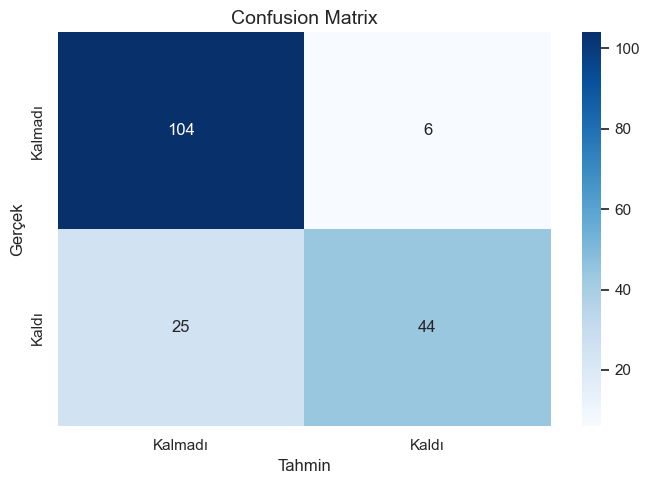

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test_scaled)

# Classification report
print(classification_report(y_test, y_pred,
      target_names=["Hayatta Kalmadı", "Hayatta Kaldı"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Kalmadı", "Kaldı"],
            yticklabels=["Kalmadı", "Kaldı"])
plt.title("Confusion Matrix", fontsize=14)
plt.ylabel("Gerçek")
plt.xlabel("Tahmin")
plt.tight_layout()
plt.savefig("05_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show();

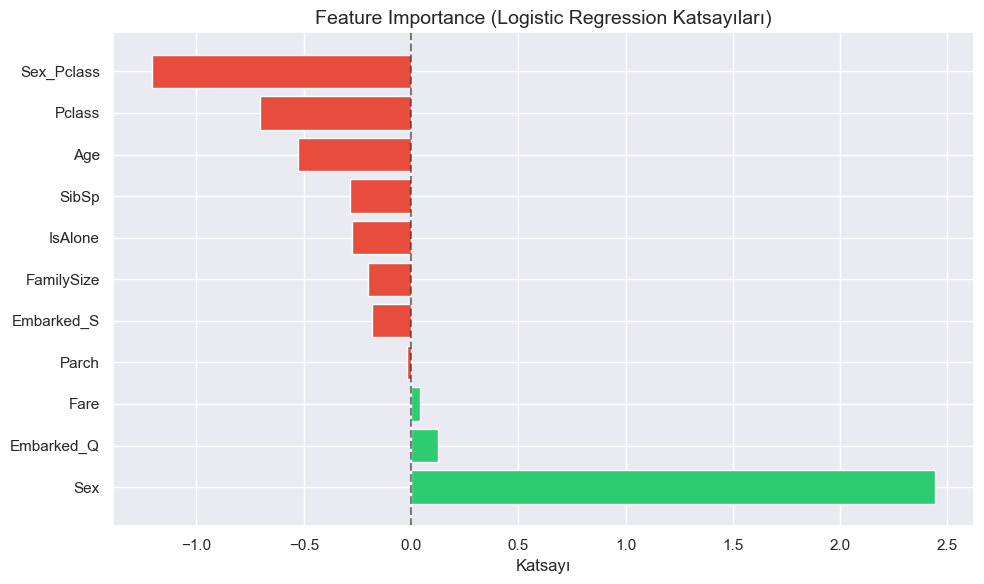

In [29]:
feature_names = X.columns
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values("Coefficient", ascending=False)

plt.figure(figsize=(10, 6))
colors = ["#2ecc71" if c > 0 else "#e74c3c" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.title("Feature Importance (Logistic Regression Katsayıları)", fontsize=14)
plt.xlabel("Katsayı")
plt.axvline(x=0, color="black", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("06_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
cd C:\Users\Tuna\Desktop\projeler\aiogreniyorum\titanic-survival-analysis

git init
git add .
git commit -m "Initial commit: EDA, feature engineering, logistic regression"
git branch -M main
git remote add origin https://github.com/Tuna9826/titanic-survival-analysis.git
git push -u origin main